In [3]:
# ============================================================================
# CTAB-GAN with Differential Privacy, KL/JS Divergence, and Bug Fixes
# ============================================================================

import os, math, numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.nn.utils import spectral_norm, clip_grad_norm_
from sklearn.preprocessing import OneHotEncoder, QuantileTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from dataclasses import dataclass
from typing import Optional, Callable
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, chi2_contingency, entropy
from scipy.spatial.distance import jensenshannon
import warnings
warnings.filterwarnings('ignore')

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cpu


In [4]:
df=pd.read_csv("/kaggle/input/datasets/toshangupta/adult-dataset/adult.csv")
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)
syn_df=pd.read_csv("/kaggle/input/datasets/toshangupta/synthetic-adult-data-findiff/synthetic.csv")
# syn_df=syn_df.drop(columns=["Unnamed: 0"])

In [5]:
syn_df.columns

Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week', 'workclass', 'education', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'native-country',
       'income'],
      dtype='object')

In [6]:
out_dir="Results"
os.makedirs(out_dir, exist_ok=True)

In [7]:
num_cols=['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss','hours-per-week']
cat_cols=['workclass', 'education', 'marital-status', 'occupation','relationship', 'race', 'gender', 'native-country', 'income']


Plotting distribution comparisons...


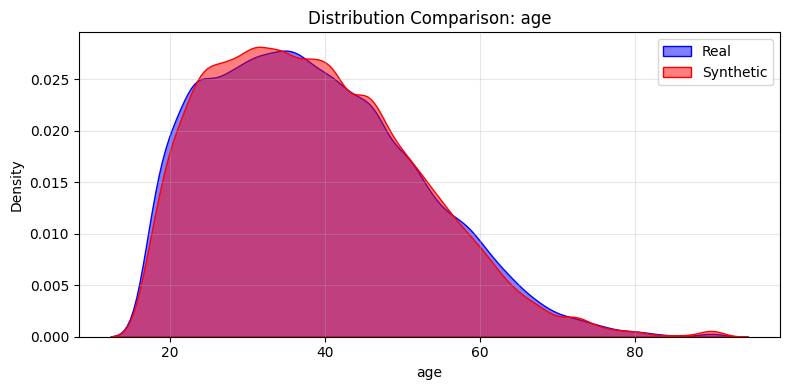

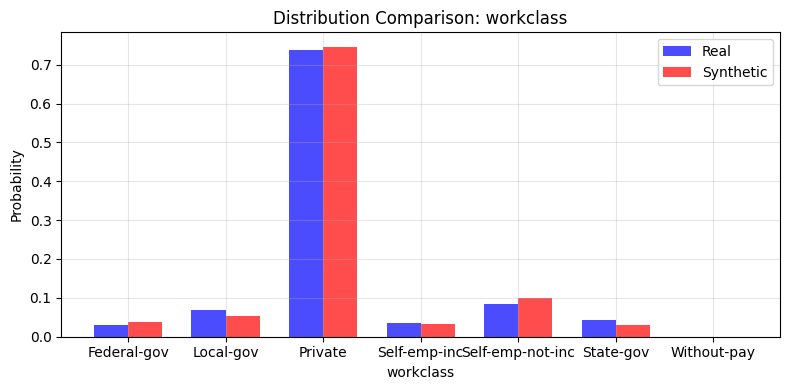

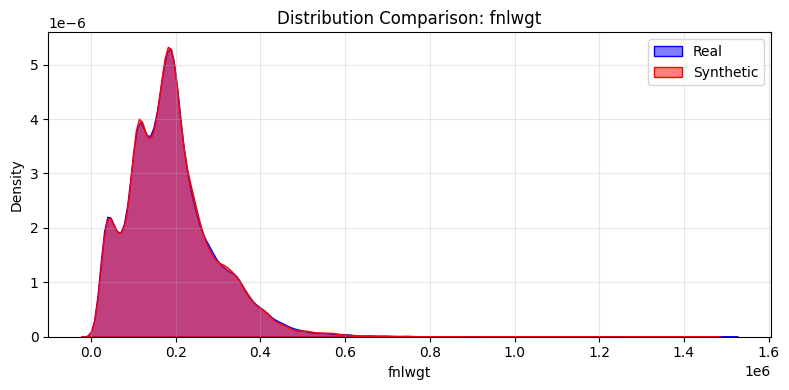

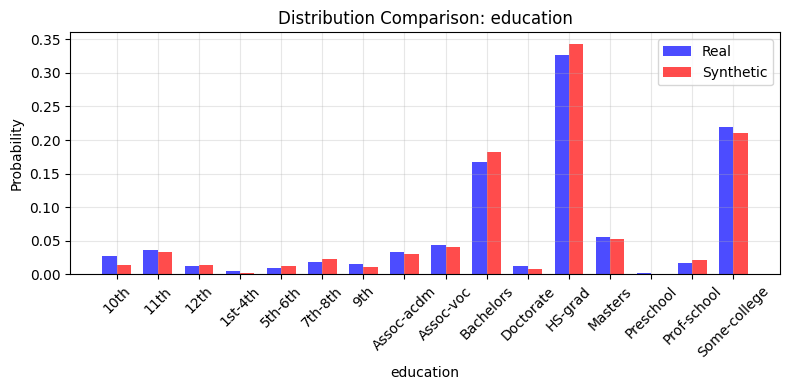

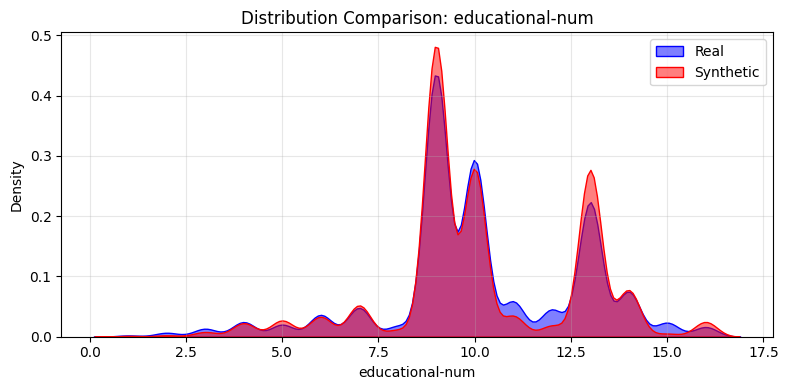

✅ Distribution plots completed


In [8]:
print("\nPlotting distribution comparisons...")
for col in df.columns[:5]:  # First 5 columns
    plt.figure(figsize=(8, 4))
    
    if col in num_cols:
        # Numeric column - use KDE
        sns.kdeplot(df[col], label='Real', fill=True, alpha=0.5, color='blue')
        sns.kdeplot(syn_df[col], label='Synthetic', fill=True, alpha=0.5, color='red')
    else:
        # Categorical column - use bar plot
        real_counts = df[col].value_counts(normalize=True)
        syn_counts = syn_df[col].value_counts(normalize=True)
        
        # ✨ FIX: Align categories
        all_categories = sorted(set(real_counts.index) | set(syn_counts.index))
        real_counts = real_counts.reindex(all_categories, fill_value=0)
        syn_counts = syn_counts.reindex(all_categories, fill_value=0)
        
        x = np.arange(len(all_categories))
        width = 0.35
        
        plt.bar(x - width/2, real_counts.values, width, label='Real', alpha=0.7, color='blue')
        plt.bar(x + width/2, syn_counts.values, width, label='Synthetic', alpha=0.7, color='red')
        
        # Smart tick labeling
        if len(all_categories) <= 20:
            plt.xticks(x, all_categories, rotation=45 if len(all_categories) > 10 else 0)
        else:
            step = max(1, len(all_categories) // 10)
            plt.xticks(x[::step], [all_categories[i] for i in range(0, len(all_categories), step)], rotation=45)
    
    plt.title(f'Distribution Comparison: {col}')
    plt.xlabel(col)
    plt.ylabel('Density' if col in num_cols else 'Probability')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f'dist_comparison_{col}.png'), dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

print("✅ Distribution plots completed")

In [9]:
# ============================================================================
# 12. EVALUATION METRICS: KL and JS Divergence
# ============================================================================

def compute_histogram_probs(data, bins=50, range_vals=None):
    """Compute histogram probabilities for divergence calculation"""
    if range_vals is None:
        range_vals = (data.min(), data.max())
    
    hist, _ = np.histogram(data, bins=bins, range=range_vals, density=True)
    # Normalize to get probabilities
    hist = hist + 1e-10  # Add small constant to avoid log(0)
    hist = hist / hist.sum()
    return hist

def kl_divergence(real_data, syn_data, bins=50):
    """
    Compute KL Divergence: KL(P || Q) where P is real, Q is synthetic
    KL(P || Q) = sum(P(i) * log(P(i) / Q(i)))
    """
    # Get common range
    min_val = min(real_data.min(), syn_data.min())
    max_val = max(real_data.max(), syn_data.max())
    range_vals = (min_val, max_val)
    
    # Compute histograms
    p = compute_histogram_probs(real_data, bins=bins, range_vals=range_vals)
    q = compute_histogram_probs(syn_data, bins=bins, range_vals=range_vals)
    
    # Compute KL divergence
    kl = entropy(p, q)
    return kl

def js_divergence(real_data, syn_data, bins=50):
    """
    Compute JS Divergence: JS(P || Q)
    JS is symmetric and bounded [0, 1] (in bits) or [0, ln(2)] (in nats)
    """
    # Get common range
    min_val = min(real_data.min(), syn_data.min())
    max_val = max(real_data.max(), syn_data.max())
    range_vals = (min_val, max_val)
    
    # Compute histograms
    p = compute_histogram_probs(real_data, bins=bins, range_vals=range_vals)
    q = compute_histogram_probs(syn_data, bins=bins, range_vals=range_vals)
    
    # Compute JS divergence
    js = jensenshannon(p, q, base=2)  # base=2 for bits
    return js

def compute_divergences_for_dataframes(df_real, df_syn, num_cols, cat_cols, bins=50):
    """
    Compute KL and JS divergences for all columns
    """
    results = {
        'column': [],
        'type': [],
        'kl_divergence': [],
        'js_divergence': []
    }
    
    # Numeric columns
    for col in num_cols:
        real_vals = df_real[col].values
        syn_vals = df_syn[col].values
        
        kl = kl_divergence(real_vals, syn_vals, bins=bins)
        js = js_divergence(real_vals, syn_vals, bins=bins)
        
        results['column'].append(col)
        results['type'].append('numeric')
        results['kl_divergence'].append(kl)
        results['js_divergence'].append(js)
    
    # Categorical columns
    for col in cat_cols:
        # Get value counts
        real_counts = df_real[col].value_counts(sort=False)
        syn_counts = df_syn[col].value_counts(sort=False)
        
        # Align categories
        all_cats = sorted(set(real_counts.index) | set(syn_counts.index))
        p = np.array([real_counts.get(c, 0) for c in all_cats]) + 1e-10
        q = np.array([syn_counts.get(c, 0) for c in all_cats]) + 1e-10
        
        # Normalize
        p = p / p.sum()
        q = q / q.sum()
        
        # Compute divergences
        kl = entropy(p, q)
        js = jensenshannon(p, q, base=2)
        
        results['column'].append(col)
        results['type'].append('categorical')
        results['kl_divergence'].append(kl)
        results['js_divergence'].append(js)
    
    return pd.DataFrame(results)


EVALUATION: STATISTICAL TESTS

Kolmogorov-Smirnov Test (Numeric Columns):
------------------------------------------------------------
age                 : KS statistic = 0.0131, p-value = 0.000893
fnlwgt              : KS statistic = 0.0053, p-value = 0.557366
educational-num     : KS statistic = 0.0305, p-value = 0.000000
capital-gain        : KS statistic = 0.0154, p-value = 0.000048
capital-loss        : KS statistic = 0.0105, p-value = 0.014126
hours-per-week      : KS statistic = 0.0303, p-value = 0.000000

------------------------------------------------------------

Chi-Squared Test (Categorical Columns):
------------------------------------------------------------
workclass           : χ² = 333.2962, p-value = 0.000000
education           : χ² = 460.6760, p-value = 0.000000
marital-status      : χ² = 398.5567, p-value = 0.000000
occupation          : χ² = 1634.6355, p-value = 0.000000
relationship        : χ² = 167.4623, p-value = 0.000000
race                : χ² = 259.5708

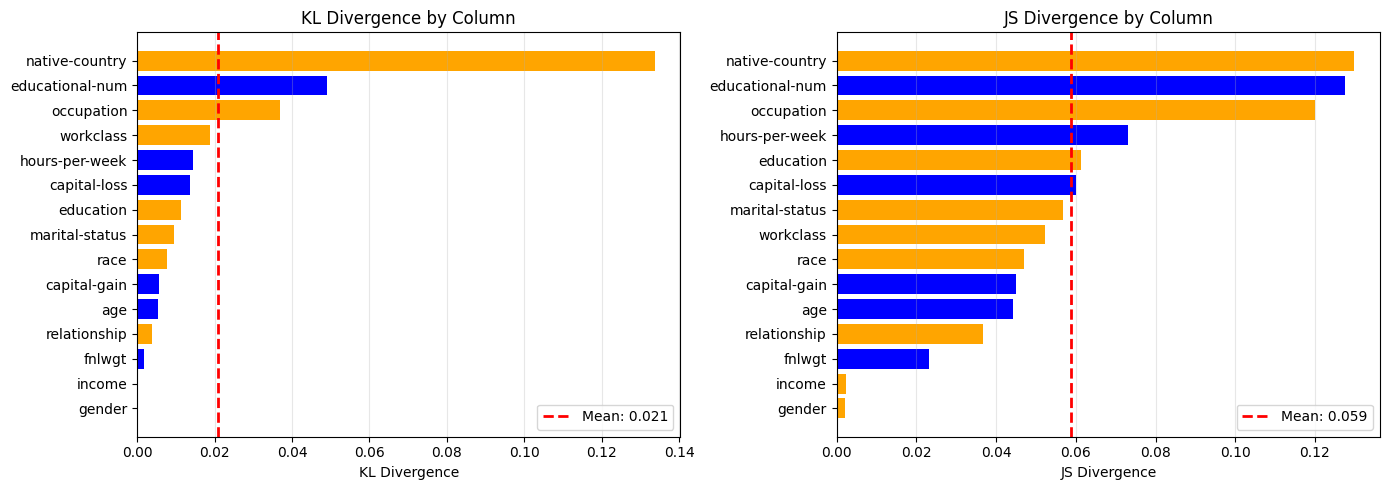

In [10]:
# ============================================================================
# 17. EVALUATION: STATISTICAL TESTS
# ============================================================================

print("\n" + "="*80)
print("EVALUATION: STATISTICAL TESTS")
print("="*80 + "\n")

# Kolmogorov-Smirnov test for numeric columns
print("Kolmogorov-Smirnov Test (Numeric Columns):")
print("-" * 60)
for col in num_cols:
    ks_stat, p_value = ks_2samp(df[col], syn_df[col])
    print(f"{col:20s}: KS statistic = {ks_stat:.4f}, p-value = {p_value:.6f}")

print("\n" + "-" * 60 + "\n")

# Chi-squared test for categorical columns
print("Chi-Squared Test (Categorical Columns):")
print("-" * 60)
for col in cat_cols:
    real_counts = df[col].value_counts()
    synth_counts = syn_df[col].value_counts()
    table = pd.concat([real_counts, synth_counts], axis=1).fillna(0)
    chi2, p, dof, expected = chi2_contingency(table.T)
    print(f"{col:20s}: χ² = {chi2:.4f}, p-value = {p:.6f}")

# ============================================================================
# 18. EVALUATION: KL AND JS DIVERGENCE
# ============================================================================

print("\n" + "="*80)
print("EVALUATION: KL AND JS DIVERGENCE")
print("="*80 + "\n")

# Compute divergences
divergence_results = compute_divergences_for_dataframes(df, syn_df, num_cols, cat_cols, bins=50)

print("KL and JS Divergence for all columns:")
print("-" * 80)
print(divergence_results.to_string(index=False))

# Save results
divergence_results.to_csv(os.path.join(out_dir, "divergence_results.csv"), index=False)

# Summary statistics
print("\n" + "-" * 80)
print("\nSummary Statistics:")
print(f"Average KL Divergence: {divergence_results['kl_divergence'].mean():.4f}")
print(f"Average JS Divergence: {divergence_results['js_divergence'].mean():.4f}")
print(f"\nMedian KL Divergence: {divergence_results['kl_divergence'].median():.4f}")
print(f"Median JS Divergence: {divergence_results['js_divergence'].median():.4f}")

# Visualize divergences
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KL Divergence
divergence_results_sorted = divergence_results.sort_values('kl_divergence')
axes[0].barh(divergence_results_sorted['column'], divergence_results_sorted['kl_divergence'], 
             color=['blue' if t == 'numeric' else 'orange' for t in divergence_results_sorted['type']])
axes[0].set_xlabel('KL Divergence')
axes[0].set_title('KL Divergence by Column')
axes[0].grid(True, alpha=0.3, axis='x')
axes[0].axvline(divergence_results['kl_divergence'].mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {divergence_results["kl_divergence"].mean():.3f}')
axes[0].legend()

# JS Divergence
divergence_results_sorted = divergence_results.sort_values('js_divergence')
axes[1].barh(divergence_results_sorted['column'], divergence_results_sorted['js_divergence'],
             color=['blue' if t == 'numeric' else 'orange' for t in divergence_results_sorted['type']])
axes[1].set_xlabel('JS Divergence')
axes[1].set_title('JS Divergence by Column')
axes[1].grid(True, alpha=0.3, axis='x')
axes[1].axvline(divergence_results['js_divergence'].mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {divergence_results["js_divergence"].mean():.3f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(out_dir, "divergence_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()